# Notebook 2 — Shared Molecular Patterns with CCA and Neural Projection

**Notebook 1 asked whether we can learn a compact representation of each patient. Here we ask a different question: what molecular patterns are shared between two omics layers?**

We use the frozen 617-patient TCGA-BRCA cohort and focus on RNA-seq (1,000 selected features) and miRNA (300 selected features). No raw-data download or preprocessing is required.

Canonical Correlation Analysis (CCA) is our statistical baseline: it finds linear RNA and miRNA combinations that are maximally correlated across patients. We then use a small neural model to ask whether nonlinear shared representation learning captures a related shared structure. PAM50 is never used to fit either model; it is only overlaid afterward as an external biological reference.


## Load the workshop tools

**Next,** import the analysis and plotting libraries, set a fixed seed, and locate the repository data directory. This makes the demonstration reproducible and ensures that later code reads the frozen processed data. **Look for** the reported seed and processed-data path.


In [1]:
import time
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(".").resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Project root  : {PROJECT_DIR}")
print(f"Processed dir : {PROCESSED_DIR}")
print(f"Random seed   : {SEED}")

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"    : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.size"     : 11,
})

Project root  : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop
Processed dir : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed
Random seed   : 42


## Load frozen RNA-seq and miRNA data

**Next,** load the frozen RNA-seq, miRNA, and cohort-metadata files, then check that RNA and miRNA refer to the same patients in the same order. Shared-pattern methods require matched measurements for each patient. **Look for** matching 617-row matrices and successful alignment checks.


In [2]:
t_start = time.time()

# ── Load processed matrices ────────────────────────────────────────────────────
rna_path   = PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv"
mirna_path = PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv"
cohort_path = PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv"

for p in [rna_path, mirna_path, cohort_path]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required file not found: {p}\n"
            "Please run Notebook 1 first to generate the processed matrices."
        )

rna_df    = pd.read_csv(rna_path,   sep="\t", index_col=0)
mirna_df  = pd.read_csv(mirna_path, sep="\t", index_col=0)
cohort_df = pd.read_csv(cohort_path, sep="\t", index_col="sample_id")

print("Loaded processed matrices:")
print(f"  RNA-seq  : {rna_df.shape[0]} samples × {rna_df.shape[1]} genes")
print(f"  miRNA    : {mirna_df.shape[0]} samples × {mirna_df.shape[1]} miRNAs")
print(f"  Cohort   : {cohort_df.shape[0]} samples")

# ── Integrity checks ──────────────────────────────────────────────────────────
assert list(rna_df.index) == list(mirna_df.index), \
    "Sample order mismatch between RNA and miRNA matrices"
assert rna_df.isnull().sum().sum()   == 0, "Missing values in RNA matrix"
assert mirna_df.isnull().sum().sum() == 0, "Missing values in miRNA matrix"
assert rna_df.columns.nunique()   == rna_df.shape[1],   "Duplicate RNA features"
assert mirna_df.columns.nunique() == mirna_df.shape[1], "Duplicate miRNA features"

print("\n✅ All integrity checks passed:")
print(f"  Identical sample ordering across both modalities")
print(f"  Zero missing values in RNA-seq")
print(f"  Zero missing values in miRNA")
print(f"  No duplicate feature IDs")

Loaded processed matrices:
  RNA-seq  : 617 samples × 1000 genes
  miRNA    : 617 samples × 300 miRNAs
  Cohort   : 617 samples

✅ All integrity checks passed:
  Identical sample ordering across both modalities
  Zero missing values in RNA-seq
  Zero missing values in miRNA
  No duplicate feature IDs


## Prepare a stable CCA input

**Next,** select high-variance RNA and miRNA features without using labels. Reducing the feature sets keeps this compact CCA demonstration numerically stable while preserving a data-driven subset of each layer. **Look for** 100 RNA and 30 miRNA features, plus examples of the selected names.


In [3]:
N_RNA_CCA   = 100
N_MIRNA_CCA = 30

# Variance-based selection — no labels used
top_rna_genes  = rna_df.var(axis=0).nlargest(N_RNA_CCA).index
top_mirna_ids  = mirna_df.var(axis=0).nlargest(N_MIRNA_CCA).index

X_raw = rna_df[top_rna_genes].values.astype(float)    # (617, 100)
Y_raw = mirna_df[top_mirna_ids].values.astype(float)   # (617, 30)

sample_ids = rna_df.index.tolist()

print(f"RNA-seq  after feature selection: {X_raw.shape}  ({N_RNA_CCA} genes)")
print(f"miRNA    after feature selection: {Y_raw.shape}  ({N_MIRNA_CCA} miRNAs)")
print()
print(f"Top 5 RNA genes selected : {list(top_rna_genes[:5])}")
print(f"Top 5 miRNA IDs selected : {list(top_mirna_ids[:5])}")

RNA-seq  after feature selection: (617, 100)  (100 genes)
miRNA    after feature selection: (617, 30)  (30 miRNAs)

Top 5 RNA genes selected : ['CLEC3A', 'CPB1', 'SCGB2A2', 'SCGB1D2', 'TFF1']
Top 5 miRNA IDs selected : ['MIMAT0005923', 'MIMAT0000454', 'MIMAT0000226', 'MIMAT0000266', 'MIMAT0000262']


## Standardise each omics layer

**Next,** centre and scale the selected RNA and miRNA features independently. CCA compares weighted combinations across layers, so standardisation prevents a feature from dominating simply because of its numeric scale. **Look for** means near zero, standard deviations near one, and comparable standardised-value distributions.


X (RNA-seq, standardised) : shape=(617, 100)  mean=0.0000  std=1.0000
Y (miRNA,   standardised) : shape=(617, 30)  mean=0.0000  std=1.0000


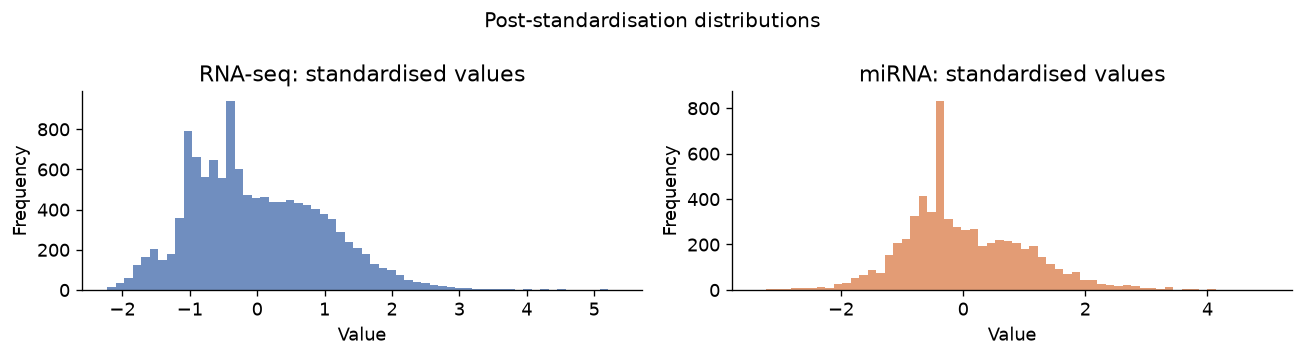

In [4]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X = scaler_X.fit_transform(X_raw)   # (617, 100)
Y = scaler_Y.fit_transform(Y_raw)   # (617, 30)

print(f"X (RNA-seq, standardised) : shape={X.shape}  mean={X.mean():.4f}  std={X.std():.4f}")
print(f"Y (miRNA,   standardised) : shape={Y.shape}  mean={Y.mean():.4f}  std={Y.std():.4f}")

# Quick distribution check
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(X.ravel()[::5], bins=60, color="#4C72B0", alpha=0.8)
axes[0].set_title("RNA-seq: standardised values"); axes[0].set_xlabel("Value")
axes[1].hist(Y.ravel()[::3], bins=60, color="#DD8452", alpha=0.8)
axes[1].set_title("miRNA: standardised values"); axes[1].set_xlabel("Value")
for ax in axes:
    ax.set_ylabel("Frequency")
plt.suptitle("Post-standardisation distributions", fontsize=12)
plt.tight_layout()
plt.show()

## CCA baseline: a transparent shared space

**Next,** fit five CCA component pairs. Each pair contains one RNA score and one miRNA score chosen to be as correlated as possible under a linear model. **Look for** two 617 × 5 score matrices: these are the paired shared coordinates for the two layers.


In [5]:
N_COMPONENTS = 5

t_cca = time.time()
cca = CCA(n_components=N_COMPONENTS, max_iter=1000)
cca.fit(X, Y)
X_c, Y_c = cca.transform(X, Y)   # canonical variates
cca_time = time.time() - t_cca

print(f"CCA fitted in {cca_time:.2f} seconds")
print(f"  RNA canonical variates  (X_c): {X_c.shape}")
print(f"  miRNA canonical variates (Y_c): {Y_c.shape}")

CCA fitted in 0.16 seconds
  RNA canonical variates  (X_c): (617, 5)
  miRNA canonical variates (Y_c): (617, 5)


## Measure the shared linear signal

**Next,** calculate the correlation for each paired CCA component and plot the results. The first component is the strongest shared linear RNA–miRNA pattern; later components describe additional orthogonal patterns. **Look for** the existing reported canonical correlations and the bar chart that compares the five components.


Canonical correlations (RNA ↔ miRNA):
                     Pearson correlation
Canonical component                     
CV1                               0.9519
CV2                               0.8746
CV3                               0.8157
CV4                               0.7851
CV5                               0.7480


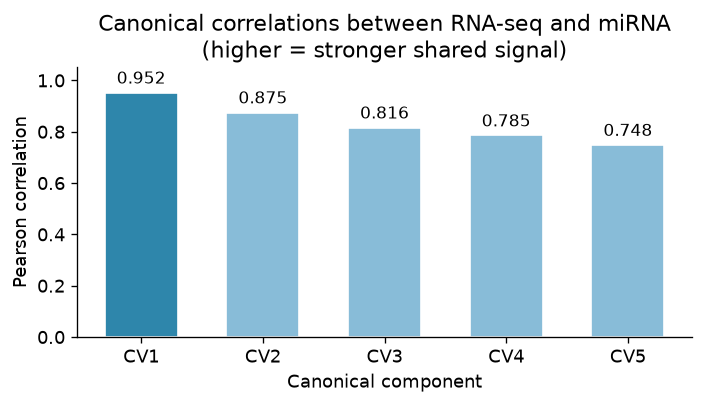

In [6]:
canonical_corrs = []
for i in range(N_COMPONENTS):
    r, p = pearsonr(X_c[:, i], Y_c[:, i])
    canonical_corrs.append(r)

corr_df = pd.DataFrame({
    "Canonical component": [f"CV{i+1}" for i in range(N_COMPONENTS)],
    "Pearson correlation" : [round(r, 4) for r in canonical_corrs],
})
corr_df = corr_df.set_index("Canonical component")

print("Canonical correlations (RNA ↔ miRNA):")
print(corr_df.to_string())

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#2E86AB" if i == 0 else "#88BCD8" for i in range(N_COMPONENTS)]
ax.bar(corr_df.index, corr_df["Pearson correlation"], color=colors, edgecolor="white", width=0.6)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Canonical component"); ax.set_ylabel("Pearson correlation")
ax.set_title("Canonical correlations between RNA-seq and miRNA\n(higher = stronger shared signal)")
for i, r in enumerate(canonical_corrs):
    ax.text(i, r + 0.02, f"{r:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## Visualise the first shared representation

**Next,** plot each patient's first RNA canonical score against its paired miRNA canonical score. This is the central CCA plot: a close relationship indicates a pattern observed in both molecular layers. **Look for** the scatter of patients, the fitted trend line, and the already reported first-component correlation.


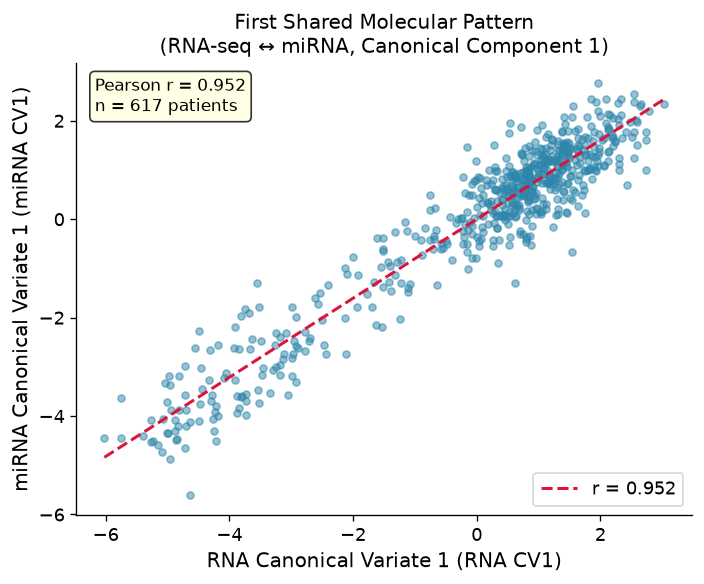

Canonical correlation 1 (r) = 0.9519


In [7]:
r1 = canonical_corrs[0]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_c[:, 0], Y_c[:, 0], s=18, alpha=0.5, color="#2E86AB", rasterized=True)

# Trend line
m, b = np.polyfit(X_c[:, 0], Y_c[:, 0], 1)
xs = np.linspace(X_c[:, 0].min(), X_c[:, 0].max(), 100)
ax.plot(xs, m * xs + b, color="crimson", linewidth=1.8, linestyle="--", label=f"r = {r1:.3f}")

ax.set_xlabel("RNA Canonical Variate 1 (RNA CV1)", fontsize=12)
ax.set_ylabel("miRNA Canonical Variate 1 (miRNA CV1)", fontsize=12)
ax.set_title("First Shared Molecular Pattern\n(RNA-seq ↔ miRNA, Canonical Component 1)",
             fontsize=12)
ax.legend(fontsize=11)
ax.text(0.03, 0.97, f"Pearson r = {r1:.3f}\nn = {len(X_c)} patients",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_CCA_CV1_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Canonical correlation 1 (r) = {r1:.4f}")

## Inspect CCA loadings

**Next,** rank the RNA and miRNA features with the largest absolute contribution to the first CCA axis. These loadings help explain the mathematical shared axis, but they do not establish causal or regulatory relationships. **Look for** the top features and their signed loading plots.


Top 10 RNA features contributing to Canonical Axis 1:
         Loading
Gene            
TFF3      0.3375
C1orf64   0.2832
AGR3      0.2747
A2ML1    -0.2150
KRT81    -0.1971
MUC16    -0.1947
STAC2     0.1776
CRABP1   -0.1732
CST9      0.1625
PRAME    -0.1560

Top 10 miRNA features contributing to Canonical Axis 1:
              Loading
miRNA                
MIMAT0003242  -0.3969
MIMAT0004929   0.3884
MIMAT0000758  -0.3857
MIMAT0004784  -0.3363
MIMAT0000267  -0.2766
MIMAT0000434  -0.2549
MIMAT0000728   0.2240
MIMAT0017985   0.2226
MIMAT0004809   0.2146
MIMAT0026480   0.1647


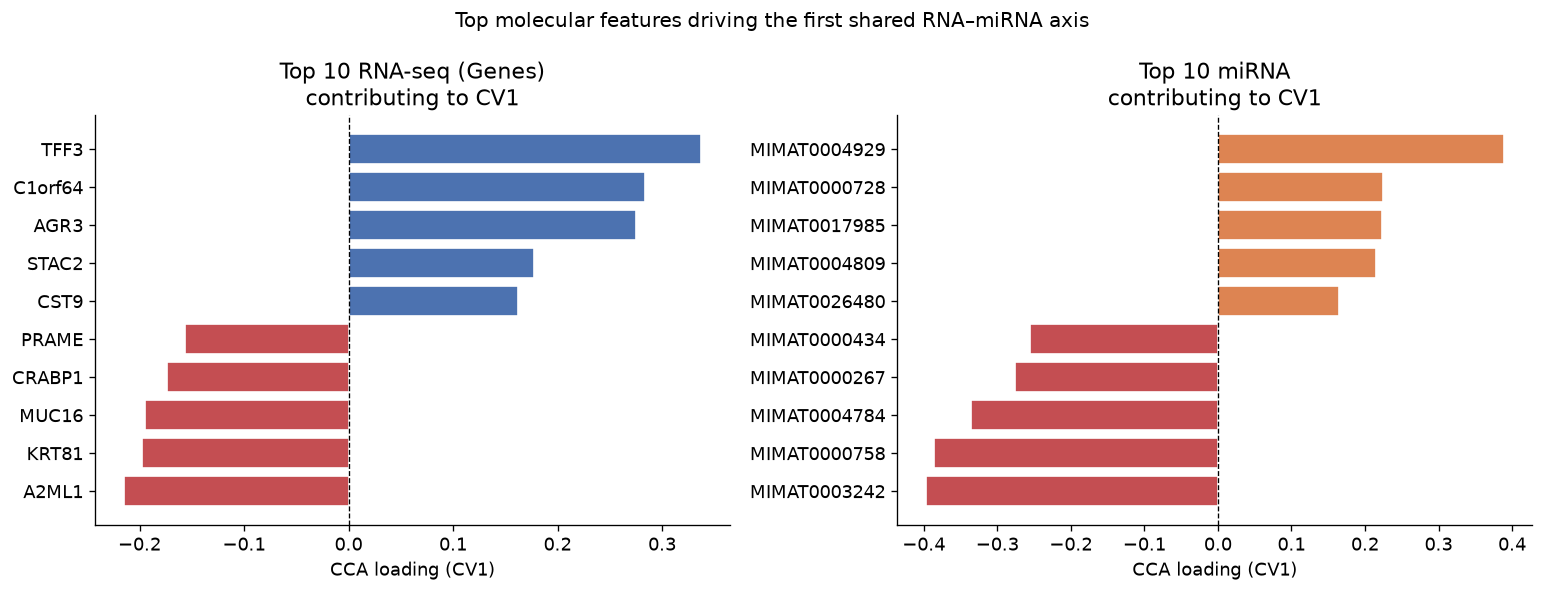

In [8]:
N_TOP = 10

# CCA coefficients: x_rotations_ = loadings for X (RNA), y_rotations_ = loadings for Y (miRNA)
rna_loadings_cv1   = cca.x_rotations_[:, 0]   # length = N_RNA_CCA
mirna_loadings_cv1 = cca.y_rotations_[:, 0]   # length = N_MIRNA_CCA

# Top RNA features by |loading|
rna_load_df = pd.DataFrame({
    "Gene"   : top_rna_genes,
    "Loading": rna_loadings_cv1,
}).set_index("Gene")
rna_top = rna_load_df["Loading"].abs().nlargest(N_TOP).index
rna_top_df = rna_load_df.loc[rna_top].sort_values("Loading", key=abs, ascending=False)

# Top miRNA features by |loading|
mirna_load_df = pd.DataFrame({
    "miRNA"  : top_mirna_ids,
    "Loading": mirna_loadings_cv1,
}).set_index("miRNA")
mirna_top = mirna_load_df["Loading"].abs().nlargest(N_TOP).index
mirna_top_df = mirna_load_df.loc[mirna_top].sort_values("Loading", key=abs, ascending=False)

print("Top 10 RNA features contributing to Canonical Axis 1:")
print(rna_top_df.round(4).to_string())
print()
print("Top 10 miRNA features contributing to Canonical Axis 1:")
print(mirna_top_df.round(4).to_string())

# ── Horizontal bar charts ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, color, label in [
    (axes[0], rna_top_df,   "#4C72B0", "RNA-seq (Genes)"),
    (axes[1], mirna_top_df, "#DD8452", "miRNA"),
]:
    sorted_df = df.sort_values("Loading")
    bar_colors = [color if v >= 0 else "#C44E52" for v in sorted_df["Loading"]]
    ax.barh(sorted_df.index, sorted_df["Loading"], color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("CCA loading (CV1)"); ax.set_title(f"Top {N_TOP} {label}\ncontributing to CV1")

plt.suptitle("Top molecular features driving the first shared RNA–miRNA axis",
             fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_CCA_loadings_CV1.png", dpi=150, bbox_inches="tight")
plt.show()

## Post-hoc PAM50 reference

**Next,** colour the CCA scatter plot by PAM50 subtype. PAM50 was not used for feature selection, CCA fitting, or any optimisation; it is only an external reference for viewing the learned shared space. **Look for** whether the displayed labels provide useful context without treating the plot as a supervised result.


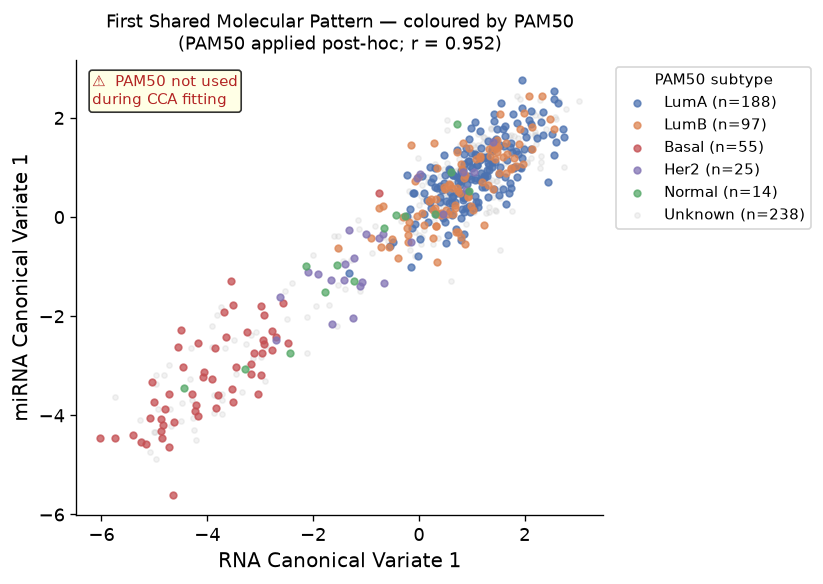

In [9]:
SUBTYPE_ORDER  = ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]
SUBTYPE_COLORS = {
    "LumA"   : "#4C72B0", "LumB"   : "#DD8452",
    "Basal"  : "#C44E52", "Her2"   : "#8172B3",
    "Normal" : "#55A868", "Unknown": "#CCCCCC",
}

pam50_labels = cohort_df["PAM50_subtype"].reindex(sample_ids).fillna("Unknown")

fig, ax = plt.subplots(figsize=(7, 5))
for st in SUBTYPE_ORDER:
    mask = pam50_labels.values == st
    if mask.sum() == 0:
        continue
    alpha = 0.25 if st == "Unknown" else 0.75
    size  = 10   if st == "Unknown" else 16
    ax.scatter(X_c[mask, 0], Y_c[mask, 0],
               s=size, color=SUBTYPE_COLORS[st], alpha=alpha,
               label=f"{st} (n={mask.sum()})", rasterized=True,
               zorder=1 if st == "Unknown" else 2)

ax.set_xlabel("RNA Canonical Variate 1", fontsize=12)
ax.set_ylabel("miRNA Canonical Variate 1", fontsize=12)
ax.set_title(f"First Shared Molecular Pattern — coloured by PAM50\n"
             f"(PAM50 applied post-hoc; r = {r1:.3f})", fontsize=11)
ax.legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9, title_fontsize=9)
ax.text(0.03, 0.97, "⚠️  PAM50 not used\nduring CCA fitting",
        transform=ax.transAxes, va="top", fontsize=9, color="firebrick",
        bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", alpha=0.8))
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_CCA_CV1_PAM50.png", dpi=150, bbox_inches="tight")
plt.show()

## Neural shared projection

**Next,** define two small neural encoders that map RNA and miRNA into the same two-dimensional space. Their objective encourages matched patient representations to correlate, allowing nonlinear transformations that CCA cannot express. **Look for** the model settings and confirmation that PAM50 is absent from the objective.


In [11]:
import torch
from torch import nn
torch.manual_seed(SEED); torch.set_num_threads(1)
LATENT_DIM,RNA_HIDDEN,MIRNA_HIDDEN=2,32,16
LEARNING_RATE,MAX_EPOCHS,PATIENCE,MIN_DELTA=1e-3,300,30,1e-4
class SmallEncoder(nn.Module):
    def __init__(self,n_in,n_hidden,n_latent):
        super().__init__(); self.network=nn.Sequential(nn.Linear(n_in,n_hidden),nn.ReLU(),nn.Linear(n_hidden,n_latent))
    def forward(self,v): return self.network(v)
def component_correlations(a,b,eps=1e-8):
    a=a-a.mean(0,keepdim=True); b=b-b.mean(0,keepdim=True)
    return (a*b).sum(0)/torch.sqrt((a.square().sum(0)+eps)*(b.square().sum(0)+eps))
print(f"Architecture: RNA {X.shape[1]} -> {RNA_HIDDEN} ReLU -> {LATENT_DIM}; miRNA {Y.shape[1]} -> {MIRNA_HIDDEN} ReLU -> {LATENT_DIM}")

Architecture: RNA 100 -> 32 ReLU -> 2; miRNA 30 -> 16 ReLU -> 2


### Train the neural projection

**Next,** train the paired encoders using a fixed split only for early stopping. This checks whether the nonlinear projection can learn shared structure without labels while avoiding unnecessary over-training. **Look for** the existing reported neural correlations, best epoch, and training summary.


In [12]:
# Fixed split used only for early stopping; PAM50 is intentionally absent.
idx=np.random.default_rng(SEED).permutation(len(X)); cut=int(.8*len(X)); train_idx,val_idx=idx[:cut],idx[cut:]
xt=torch.tensor(X,dtype=torch.float32); yt=torch.tensor(Y,dtype=torch.float32)
rna_encoder=SmallEncoder(X.shape[1],RNA_HIDDEN,LATENT_DIM); mirna_encoder=SmallEncoder(Y.shape[1],MIRNA_HIDDEN,LATENT_DIM)
opt=torch.optim.Adam(list(rna_encoder.parameters())+list(mirna_encoder.parameters()),lr=LEARNING_RATE)
best_val,bad,best_state=-np.inf,0,None; train_history=[]; val_history=[]; t_neural=time.time()
for epoch in range(1,MAX_EPOCHS+1):
    rna_encoder.train(); mirna_encoder.train(); opt.zero_grad()
    loss=-component_correlations(rna_encoder(xt[train_idx]),mirna_encoder(yt[train_idx])).mean(); loss.backward(); opt.step()
    rna_encoder.eval(); mirna_encoder.eval()
    with torch.no_grad():
        tr=component_correlations(rna_encoder(xt[train_idx]),mirna_encoder(yt[train_idx])).mean().item()
        va=component_correlations(rna_encoder(xt[val_idx]),mirna_encoder(yt[val_idx])).mean().item()
    train_history.append(tr); val_history.append(va)
    if va>best_val+MIN_DELTA:
        best_val,best_epoch,bad=va,epoch,0
        best_state={"rna":{k:v.detach().clone() for k,v in rna_encoder.state_dict().items()},"mirna":{k:v.detach().clone() for k,v in mirna_encoder.state_dict().items()}}
    else:
        bad+=1
        if bad>=PATIENCE: break
neural_time=time.time()-t_neural; rna_encoder.load_state_dict(best_state["rna"]); mirna_encoder.load_state_dict(best_state["mirna"])
with torch.no_grad(): Z_rna=rna_encoder(xt).numpy(); Z_mirna=mirna_encoder(yt).numpy()
for k in range(LATENT_DIM):
    if np.corrcoef(Z_rna[:,k],Z_mirna[:,k])[0,1]<0: Z_mirna[:,k]*=-1
neural_corrs=[pearsonr(Z_rna[:,k],Z_mirna[:,k])[0] for k in range(LATENT_DIM)]; neural_corr_1=neural_corrs[0]
print(f"Early stopping: epoch {best_epoch}/{epoch}; training time: {neural_time:.2f} s")
print(f"Validation mean r: {best_val:.4f}; full-cohort neural component 1 r: {neural_corr_1:.4f}")

Early stopping: epoch 179/209; training time: 1.13 s
Validation mean r: 0.9146; full-cohort neural component 1 r: 0.9672


## Compare CCA and neural projection

**Next,** place the first paired CCA scores and neural scores side by side using the same frozen cohort. CCA remains the transparent linear reference; the neural model tests a nonlinear shared representation. **Look for** the unchanged reported correlations and the two matching scatter plots, without treating the comparison as a benchmark claim.


,Method,First shared-component correlation
0,Linear CCA,0.9519
1,Neural projection,0.9672


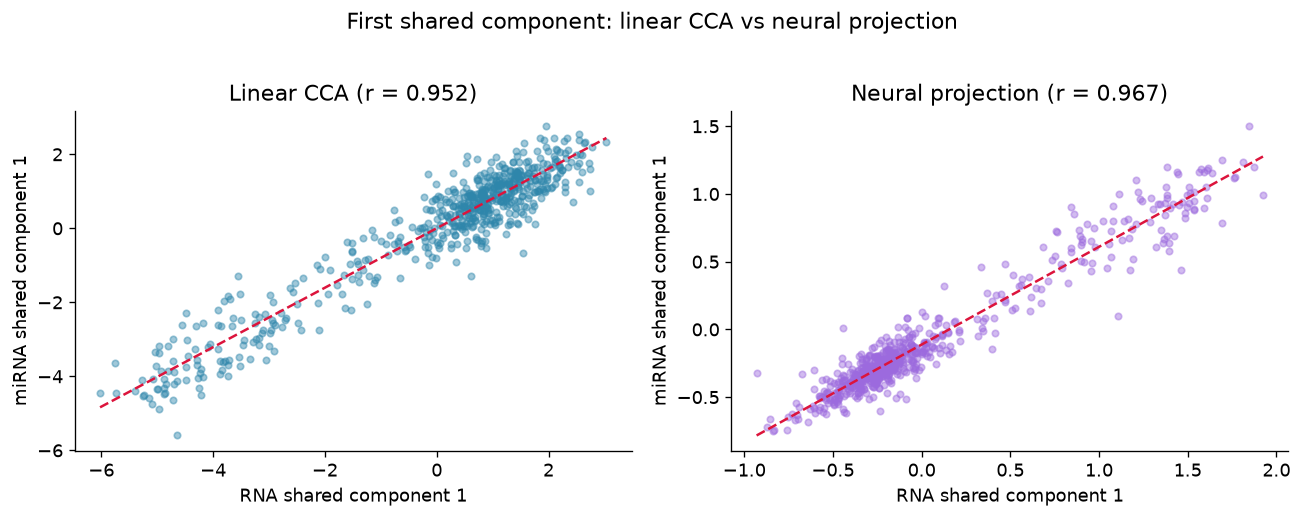

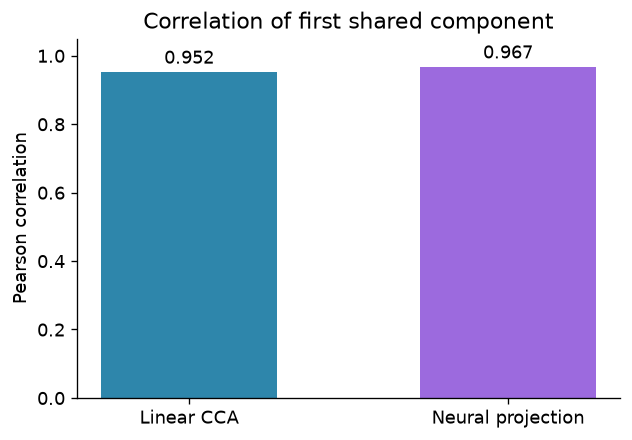

In [13]:
FIGURES_DIR=PROCESSED_DIR/"figures"; FIGURES_DIR.mkdir(parents=True,exist_ok=True)
comparison_df=pd.DataFrame({"Method":["Linear CCA","Neural projection"],"First shared-component correlation":[canonical_corrs[0],neural_corr_1]})
display(comparison_df.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4.2))
for ax,left,right,title,corr,color in [(axes[0],X_c[:,0],Y_c[:,0],"Linear CCA",canonical_corrs[0],"#2E86AB"),(axes[1],Z_rna[:,0],Z_mirna[:,0],"Neural projection",neural_corr_1,"#9C6ADE")]:
    ax.scatter(left,right,s=15,alpha=.45,color=color,rasterized=True); slope,intercept=np.polyfit(left,right,1); values=np.linspace(left.min(),left.max(),100)
    ax.plot(values,slope*values+intercept,color="crimson",lw=1.5,ls="--"); ax.set(xlabel="RNA shared component 1",ylabel="miRNA shared component 1",title=f"{title} (r = {corr:.3f})")
fig.suptitle("First shared component: linear CCA vs neural projection",y=1.02); plt.tight_layout(); plt.savefig(FIGURES_DIR/"TCGA_BRCA_neural_CCA_component1_comparison.png",dpi=150,bbox_inches="tight"); plt.show()
fig,ax=plt.subplots(figsize=(5.4,3.8)); ax.bar(comparison_df["Method"],comparison_df["First shared-component correlation"],color=["#2E86AB","#9C6ADE"],width=.55); ax.set(ylim=(0,1.05),ylabel="Pearson correlation",title="Correlation of first shared component")
for i,v in enumerate(comparison_df["First shared-component correlation"]): ax.text(i,v+.025,f"{v:.3f}",ha="center")
plt.tight_layout(); plt.savefig(FIGURES_DIR/"TCGA_BRCA_neural_CCA_correlation_comparison.png",dpi=150,bbox_inches="tight"); plt.show()

## Visualise the neural shared representation

**Next,** display the two-dimensional CCA and neural shared spaces with PAM50 colours added only after model fitting. This is a qualitative, post-hoc view: neither model, early stopping, nor the projection objective sees subtype labels. **Look for** how the two shared spaces organise patients, while keeping interpretation tied to the displayed results.


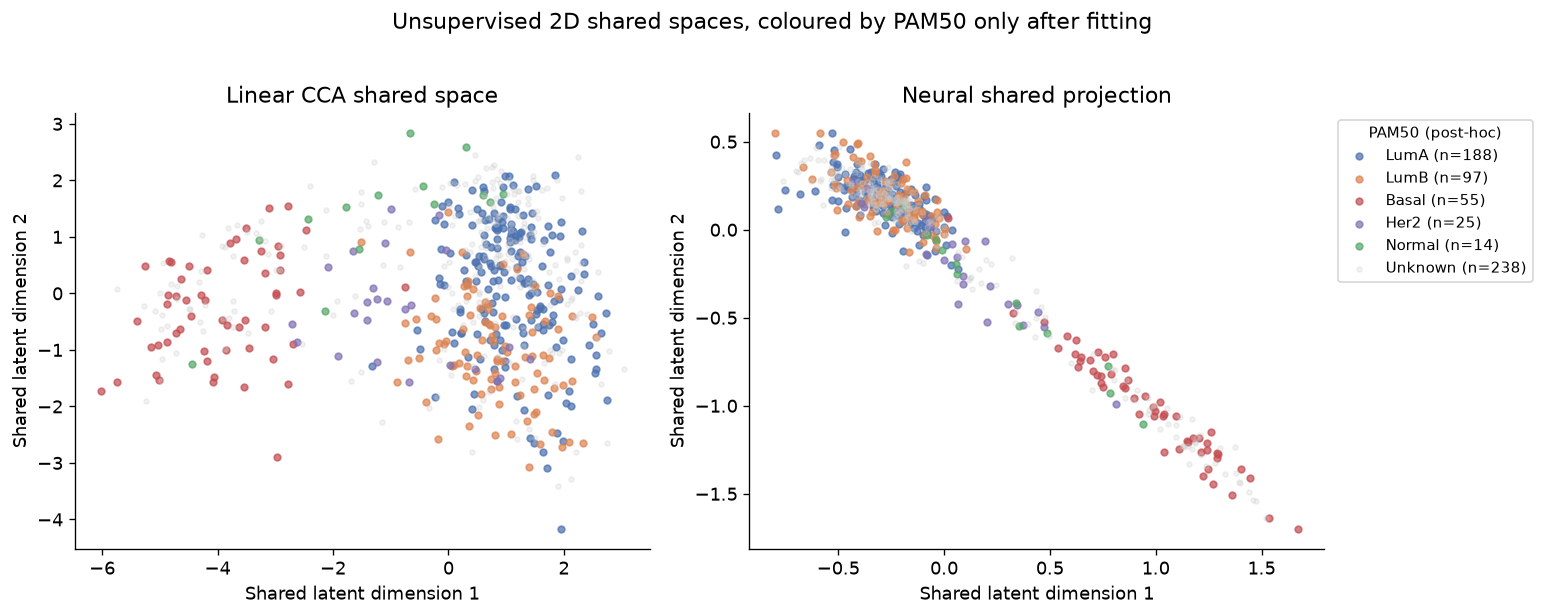

In [14]:
linear_shared_2d=X_c[:,:2].copy(); neural_shared_2d=(Z_rna+Z_mirna)/2
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,rep,title in [(axes[0],linear_shared_2d,"Linear CCA shared space"),(axes[1],neural_shared_2d,"Neural shared projection")]:
    for subtype in SUBTYPE_ORDER:
        mask=pam50_labels.values==subtype
        if mask.any(): ax.scatter(rep[mask,0],rep[mask,1],s=16 if subtype!="Unknown" else 9,alpha=.72 if subtype!="Unknown" else .25,color=SUBTYPE_COLORS[subtype],label=f"{subtype} (n={mask.sum()})",rasterized=True)
    ax.set(xlabel="Shared latent dimension 1",ylabel="Shared latent dimension 2",title=title)
axes[1].legend(title="PAM50 (post-hoc)",bbox_to_anchor=(1.01,1),loc="upper left",fontsize=9,title_fontsize=9)
fig.suptitle("Unsupervised 2D shared spaces, coloured by PAM50 only after fitting",y=1.02); plt.tight_layout(); plt.savefig(FIGURES_DIR/"TCGA_BRCA_neural_CCA_latent_PAM50_posthoc.png",dpi=150,bbox_inches="tight"); plt.show()

## Final take-away

CCA establishes a transparent statistical shared space: it makes the linear RNA–miRNA relationship explicit and inspectable. The neural model asks whether nonlinear representations can capture shared structure beyond that linear assumption.

Together, these approaches move the workshop from **compressing each patient** toward **learning relationships between omics layers**. This shared representation is the conceptual foundation for the multi-view integration methods in the next notebooks.
